In [9]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json, os, warnings

# Suppressing TensorFlow logging and warnings for a cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')

import xgboost as xgb
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)

# Ensuring reproducible results
np.random.seed(42)

# Loading the engineered dataset and feature definitions
df = pd.read_csv('../data/processed/FD001_with_rul.csv')
with open('../data/processed/useful_sensors.json') as f:
    useful_sensors = json.load(f)
with open('../data/processed/feature_cols.json') as f:
    feature_cols = json.load(f)

# Reconstructing the exact train/test split used in all previous modeling steps
engines = df['unit_id'].unique()
test_engines = np.random.choice(engines, size=int(0.2 * len(engines)), replace=False)
test_mask = df['unit_id'].isin(test_engines)
train_mask = ~test_mask

print(f"Dataset loaded successfully. Shape: {df.shape}")

Dataset loaded successfully. Shape: (20631, 92)


In [2]:
# Defining the business logic to categorize RUL into actionable alert zones
def rul_to_alert(rul):
    if rul <= 30:  return 2   # CRITICAL (Immediate maintenance required)
    elif rul <= 60: return 1  # WARNING (Schedule maintenance soon)
    else:           return 0  # NORMAL (Safe for operation)

LABEL_MAP   = {0: 'NORMAL', 1: 'WARNING', 2: 'CRITICAL'}
LABEL_NAMES = ['NORMAL', 'WARNING', 'CRITICAL']
COLORS      = ['#2a9d8f', '#e9c46a', '#e63946']

# Applying the alert logic to create the ground truth labels
df['alert_true'] = df['RUL'].apply(rul_to_alert)

print("Ground Truth Alert Distribution:")
print(df['alert_true'].value_counts().rename(LABEL_MAP))

Ground Truth Alert Distribution:
alert_true
NORMAL      14531
CRITICAL     3100
WARNING      3000
Name: count, dtype: int64


In [3]:
# Loading the pre-trained XGBoost regressor model
xgb_model = xgb.XGBRegressor()
xgb_model.load_model('../results/models/xgboost.json')

# Extracting testing features and ground truth values
X_test_xgb = df[test_mask][feature_cols]
y_true_rul  = df[test_mask]['RUL'].values
y_true_alert = df[test_mask]['alert_true'].values

# Generating RUL predictions and converting them into actionable alerts
xgb_rul_pred   = xgb_model.predict(X_test_xgb)
xgb_alert_pred = np.array([rul_to_alert(r) for r in xgb_rul_pred])

print(f"XGBoost alert predictions generated successfully. Total samples: {len(xgb_alert_pred)}")

XGBoost alert predictions generated successfully. Total samples: 4070


In [4]:
# Defining the sliding window configuration for the Deep Learning model
WINDOW   = 30
FEATURES = useful_sensors + ['op_setting_1', 'op_setting_2', 'op_setting_3']

# Scaling features based on the entire dataset boundaries
scaler = MinMaxScaler()
df_scaled = df.copy()
df_scaled[FEATURES] = scaler.fit_transform(df[FEATURES])

def build_sequences(data, window=WINDOW):
    """
    Transforms time-series data into 3D sequences for LSTM alert evaluation.
    """
    X_list, y_list, rul_list = [], [], []
    for _, group in data.groupby('unit_id'):
        group = group.sort_values('cycle')
        feats = group[FEATURES].values
        rul   = group['RUL'].values
        alert = group['alert_true'].values
        for i in range(window, len(feats)):
            X_list.append(feats[i-window:i])
            y_list.append(alert[i])
            rul_list.append(rul[i])
    return (np.array(X_list, dtype=np.float32),
            np.array(y_list),
            np.array(rul_list))

# Preparing testing sequences to match the LSTM architecture
X_test_lstm, y_alert_lstm_true, y_rul_lstm_true = build_sequences(df_scaled[test_mask])

# Loading the pre-trained LSTM model and generating sequence-based alert predictions
lstm_model = tf.keras.models.load_model('../results/models/lstm_rul.keras')
lstm_rul_pred   = lstm_model.predict(X_test_lstm, verbose=0).flatten()
lstm_alert_pred = np.array([rul_to_alert(r) for r in lstm_rul_pred])

print(f"LSTM alert predictions generated successfully. Total samples: {len(lstm_alert_pred)}")

LSTM alert predictions generated successfully. Total samples: 3470


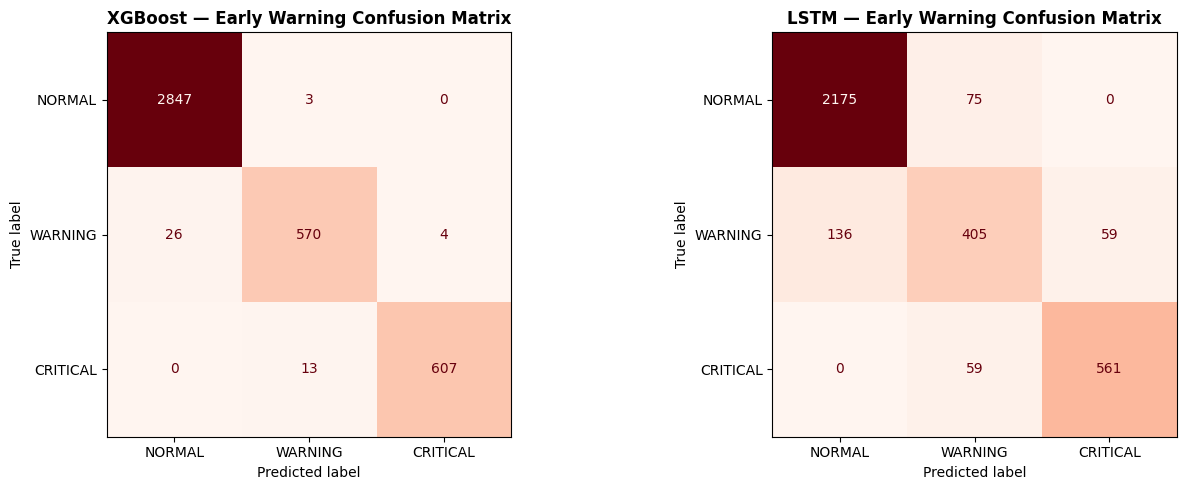

In [5]:
# Visualizing the Confusion Matrices to evaluate classification accuracy across alert zones
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [xgb_alert_pred, lstm_alert_pred],
    ['XGBoost', 'LSTM']
):
    y_true = y_true_alert if title == 'XGBoost' else y_alert_lstm_true
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABEL_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Reds')
    ax.set_title(f'{title} — Early Warning Confusion Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/confusion_matrix.png', dpi=150)
plt.show()

In [6]:
# Printing detailed classification metrics (Precision, Recall, F1-Score) for business reporting
print('=== XGBoost Early Warning System Performance ===')
print(classification_report(y_true_alert, xgb_alert_pred, target_names=LABEL_NAMES))

print('\n=== LSTM Early Warning System Performance ===')
print(classification_report(y_alert_lstm_true, lstm_alert_pred, target_names=LABEL_NAMES))

=== XGBoost Early Warning System Performance ===
              precision    recall  f1-score   support

      NORMAL       0.99      1.00      0.99      2850
     WARNING       0.97      0.95      0.96       600
    CRITICAL       0.99      0.98      0.99       620

    accuracy                           0.99      4070
   macro avg       0.99      0.98      0.98      4070
weighted avg       0.99      0.99      0.99      4070


=== LSTM Early Warning System Performance ===
              precision    recall  f1-score   support

      NORMAL       0.94      0.97      0.95      2250
     WARNING       0.75      0.68      0.71       600
    CRITICAL       0.90      0.90      0.90       620

    accuracy                           0.91      3470
   macro avg       0.87      0.85      0.86      3470
weighted avg       0.90      0.91      0.90      3470



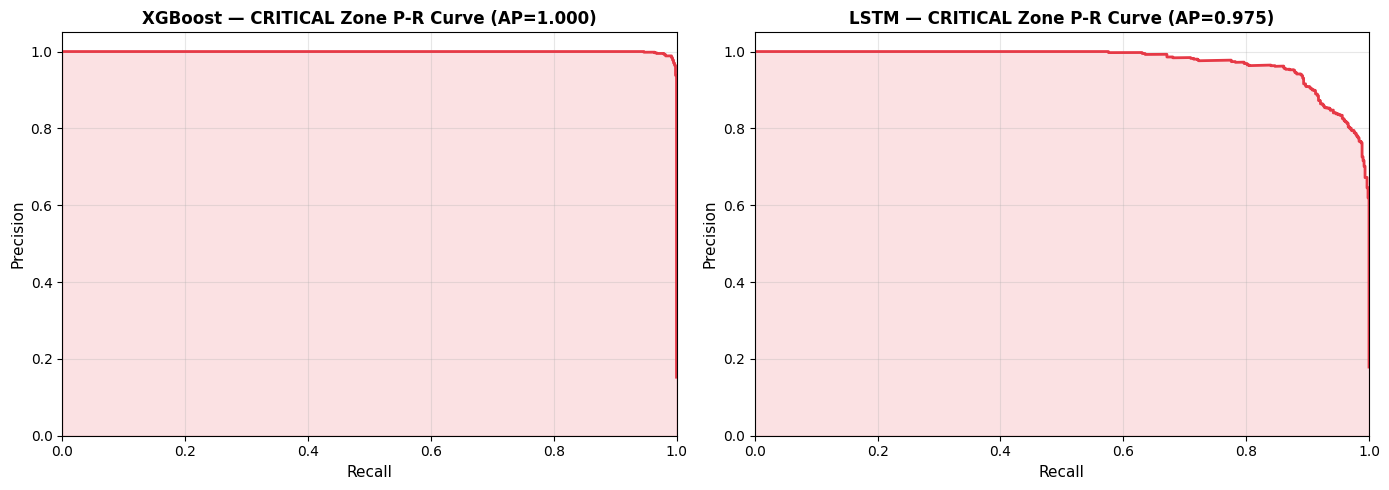

In [7]:
# Plotting the Precision-Recall curve specifically for the CRITICAL class to assess life-safety reliability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_true, rul_pred, title in zip(
    axes,
    [y_true_alert, y_alert_lstm_true],
    [xgb_rul_pred, lstm_rul_pred],
    ['XGBoost', 'LSTM']
):
    # Isolating the CRITICAL class (2) for binary classification metrics
    binary_true  = (y_true == 2).astype(int)
    
    # Transforming regression output into a probability-like score for being in the CRITICAL zone
    critical_score = 1 / (1 + np.clip(rul_pred, 1, None))

    precision, recall, _ = precision_recall_curve(binary_true, critical_score)
    ap = average_precision_score(binary_true, critical_score)

    ax.plot(recall, precision, color='#e63946', linewidth=2)
    ax.fill_between(recall, precision, alpha=0.15, color='#e63946')
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title(f'{title} — CRITICAL Zone P-R Curve (AP={ap:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/precision_recall_critical.png', dpi=150)
plt.show()

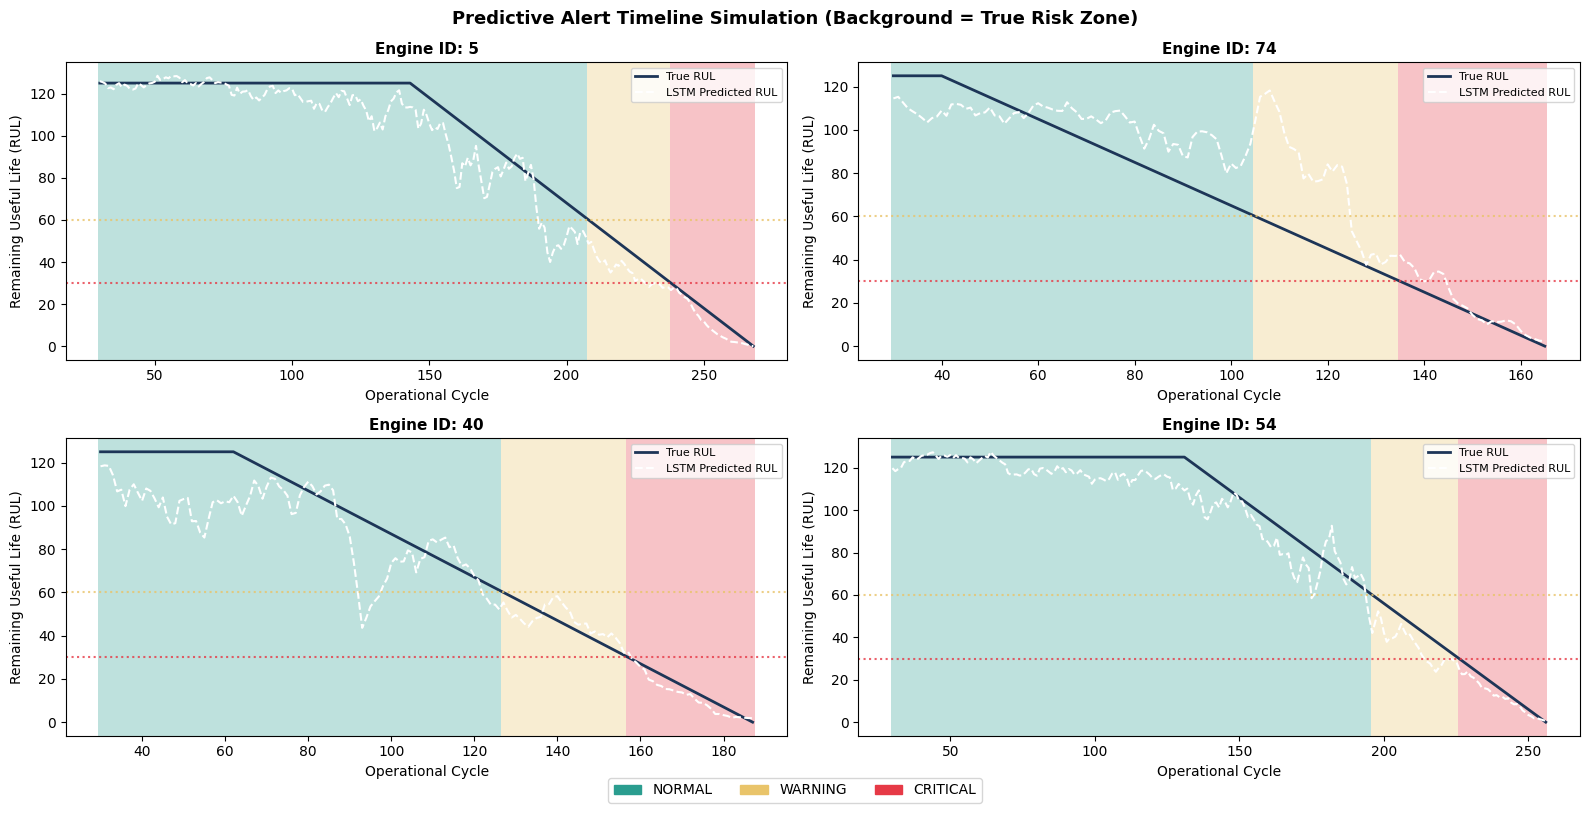

In [8]:
# Visualizing the operational timeline and alert zone transitions for sample engines
sample_engines = np.random.choice(list(test_engines), size=4, replace=False)
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

alert_colors = {0: '#2a9d8f', 1: '#e9c46a', 2: '#e63946'}
alert_labels = {0: 'NORMAL', 1: 'WARNING', 2: 'CRITICAL'}

for ax, eng in zip(axes.flatten(), sample_engines):
    group = df_scaled[df_scaled['unit_id'] == eng].sort_values('cycle')
    feats = group[FEATURES].values
    rul_true = df[df['unit_id'] == eng].sort_values('cycle')['RUL'].values

    # Simulating real-time predictive tracking
    preds_rul = []
    for i in range(WINDOW, len(feats)):
        seq = feats[i-WINDOW:i][np.newaxis, :, :]
        preds_rul.append(lstm_model.predict(seq, verbose=0)[0][0])

    true_alert  = [rul_to_alert(r) for r in rul_true[WINDOW:]]
    cycles = list(range(WINDOW, len(feats)))

    # Painting background zones corresponding to the true engine state
    for i, (c, a) in enumerate(zip(cycles, true_alert)):
        ax.axvspan(c - 0.5, c + 0.5, alpha=0.3, color=alert_colors[a], linewidth=0)

    ax.plot(cycles, rul_true[WINDOW:], color='#1d3557', linewidth=2, label='True RUL')
    ax.plot(cycles, preds_rul, color='white', linewidth=1.5, linestyle='--', label='LSTM Predicted RUL')
    
    ax.axhline(30, color='#e63946', linestyle=':', alpha=0.8)
    ax.axhline(60, color='#e9c46a', linestyle=':', alpha=0.8)
    ax.set_title(f'Engine ID: {eng}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Operational Cycle'); ax.set_ylabel('Remaining Useful Life (RUL)')
    ax.legend(fontsize=8)

# Formatting legend and layout
patches = [mpatches.Patch(color=alert_colors[i], label=alert_labels[i]) for i in [0,1,2]]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Predictive Alert Timeline Simulation (Background = True Risk Zone)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/alert_timeline.png', dpi=150, bbox_inches='tight')
plt.show()